# 13.1 Bitly Data from 1.USA.gov

Nguồn gốc: Năm 2011, dịch vụ rút gọn URL Bitly đã hợp tác với trang web của chính phủ Hoa Kỳ là USA.gov để cung cấp một nguồn cấp dữ liệu ẩn danh.
- Nội dung: Dữ liệu này được thu thập từ những người dùng rút gọn các liên kết kết thúc bằng .gov hoặc .mil.
- Định dạng: Dữ liệu ban đầu được cung cấp dưới dạng các tệp văn bản có thể tải xuống, trong đó mỗi dòng trong tệp chứa một dạng dữ liệu web phổ biến gọi là JSON (JavaScript Object Notation).
- Tình trạng: Dịch vụ cung cấp dữ liệu này đã bị ngừng vào thời điểm viết sách (2022), nhưng một tệp dữ liệu đã được lưu giữ lại để sử dụng làm ví dụ phân tích trong sách.
- Ví dụ về bản ghi (record): Một dòng dữ liệu JSON mẫu chứa nhiều trường thông tin khác nhau, ví dụ như trường tz (múi giờ), a (thông tin agent/browser), c (quốc gia), g (ID rút gọn), r (URL giới thiệu), u (URL đầy đủ), và nhiều trường khác.

## 1. Import thư viện


In [13]:
from numpy.random import randn
import numpy as np
np.random.seed(123)
import os
import matplotlib.pyplot as plt
import pandas as pd
plt.rc("figure", figsize=(10, 6)) #set figsize cho toàn bộ chart
np.set_printoptions(precision=4)
pd.options.display.max_columns = 20 #thông số cột
pd.options.display.max_rows = 20
pd.options.display.max_colwidth = 80

**Nhận xét:**
-  plt.rc("figure", figsize=(10, 6)): giúp hình đồng bộ, đủ lớn để xuất ra PDF/PNG
- np.set_printoptions(precision=4): quy định số thập phân khi in (ví dụ 0.123456 → 0.1235)
- pd.options.display.max_columns = 20: hiển thị tối đa 20 cột
- pd.options.display.max_rows = 20: hiển thị tối đa 20 dòng
- pd.options.display.max_colwidth = 80: mỗi text tối đa 80 ký tự

## 2. Đọc tệp JSON

In [2]:
path = "dataset/bitly_usagov/example.txt"

import json
with open(path) as f: # gán f và mở file path
    records = [json.loads(line) for line in f]
records[0]

{'a': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11',
 'c': 'US',
 'nk': 1,
 'tz': 'America/New_York',
 'gr': 'MA',
 'g': 'A6qOVH',
 'h': 'wfLQtf',
 'l': 'orofrog',
 'al': 'en-US,en;q=0.8',
 'hh': '1.usa.gov',
 'r': 'http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf',
 'u': 'http://www.ncbi.nlm.nih.gov/pubmed/22415991',
 't': 1331923247,
 'hc': 1331822918,
 'cy': 'Danvers',
 'll': [42.576698, -70.954903]}

**Nhận xét:**
-   Dữ liệu được chuyển đổi thành đối tượng DataFrame của pandas bằng cách truyền danh sách các bản ghi (records).

## 3. Đếm múi giờ (tz)


In [6]:
time_zones = [rec["tz"] for rec in records if "tz" in rec] #gán file records là rec và nếu tồn tại "tz" trong rec thì in ra 
time_zones[:10] # lấy từ 0 đến  9

['America/New_York',
 'America/Denver',
 'America/New_York',
 'America/Sao_Paulo',
 'America/New_York',
 'America/New_York',
 'Europe/Warsaw',
 '',
 '',
 '']

**Nhận xét:**
- Liệt kê danh sách múi giờ với cột "tz" bằng cách sử dụng phép so sánh nếu tồn tại cột "tZ" trong bản ghi. Kết quả danh sách các múi giờ bao gồm các chuỗi rỗng cho các múi giờ không xác định.

### 3.1 Đếm bằng Pure Python


In [4]:
def get_counts(sequence): # define đếm số lượng từ
    counts = {} # create empty array 
    for x in sequence:
        if x in counts:
            counts[x] += 1
        else:
            counts[x] = 1
    return counts

from collections import defaultdict
def get_counts2(sequence):
    counts = defaultdict(int) # key default int = 0 
    for x in sequence:
        counts[x] += 1 # Không cần check x có tồn tại trong mảng
    return counts

**Nhận xét:**
-  Có thể sử dụng một hàm thủ công (get_counts) hoặc sử dụng defaultdict từ thư viện collections (get_counts2) để tính số lần xuất hiện của mỗi múi giờ.

### 3.2 Tìm giá trị phổ biến nhất


In [8]:
def top_counts(count_dict, n=10):
    value_key_pairs = [(count, tz) for tz, count in count_dict.items()]
    value_key_pairs.sort()
    return value_key_pairs[-n:]

top_counts(counts)

[(33, 'America/Sao_Paulo'),
 (35, 'Europe/Madrid'),
 (36, 'Pacific/Honolulu'),
 (37, 'Asia/Tokyo'),
 (74, 'Europe/London'),
 (191, 'America/Denver'),
 (382, 'America/Los_Angeles'),
 (400, 'America/Chicago'),
 (521, ''),
 (1251, 'America/New_York')]

**Nhận xét:**
-  Tổng số múi giờ được đếm là 3440.

In [9]:
def top_counts(count_dict, n=10):
    value_key_pairs = [(count, tz) for tz, count in count_dict.items()]
    value_key_pairs.sort()
    return value_key_pairs[-n:]

top_counts(counts)

[(33, 'America/Sao_Paulo'),
 (35, 'Europe/Madrid'),
 (36, 'Pacific/Honolulu'),
 (37, 'Asia/Tokyo'),
 (74, 'Europe/London'),
 (191, 'America/Denver'),
 (382, 'America/Los_Angeles'),
 (400, 'America/Chicago'),
 (521, ''),
 (1251, 'America/New_York')]

**Nhận xét:**
- Sử dụng hàm top_counts để tìm 10 múi giờ hàng đầu bằng cách tạo danh sách các cặp (count, timezone) và sắp xếp chúng.

### 3.3 Đếm bằng Collection.Counter


In [10]:
from collections import Counter # eassy
counts = Counter(time_zones)
counts.most_common(10)

[('America/New_York', 1251),
 ('', 521),
 ('America/Chicago', 400),
 ('America/Los_Angeles', 382),
 ('America/Denver', 191),
 ('Europe/London', 74),
 ('Asia/Tokyo', 37),
 ('Pacific/Honolulu', 36),
 ('Europe/Madrid', 35),
 ('America/Sao_Paulo', 33)]

**Nhận xét:**
- 10 múi giờ phổ biến nhất (với số lượng tương ứng) bao gồm: 'America/New_York' (1251), '' (521), 'America/Chicago' (400), 'America/Los_Angeles' (382), v.v..

### 3.4 Đếm bằng pandas


In [15]:
frame = pd.DataFrame(records)
frame.info()
frame["tz"].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a            3440 non-null   object 
 1   c            2919 non-null   object 
 2   nk           3440 non-null   float64
 3   tz           3440 non-null   object 
 4   gr           2919 non-null   object 
 5   g            3440 non-null   object 
 6   h            3440 non-null   object 
 7   l            3440 non-null   object 
 8   al           3094 non-null   object 
 9   hh           3440 non-null   object 
 10  r            3440 non-null   object 
 11  u            3440 non-null   object 
 12  t            3440 non-null   float64
 13  hc           3440 non-null   float64
 14  cy           2919 non-null   object 
 15  ll           2919 non-null   object 
 16  _heartbeat_  120 non-null    float64
 17  kw           93 non-null     object 
dtypes: float64(4), object(14)
memory usage: 500.8+ K

0     America/New_York
1       America/Denver
2     America/New_York
3    America/Sao_Paulo
4     America/New_York
Name: tz, dtype: object

In [16]:
tz_counts = frame["tz"].value_counts()
tz_counts.head()

tz
America/New_York       1251
                        521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

**Nhận xét:**
- Sử dụng phương thức value_counts() trên cột tz của DataFrame để nhận kết quả tương tự một cách hiệu quả hơn.


<table> <thead> <tr> <th style="text-align:center;">Tên cột</th> <th style="text-align:center;">Ý nghĩa dễ hiểu</th> </tr> </thead> <tbody> <tr><td style="text-align:center;"><code>a</code></td><td style="text-align:center;">Chuỗi mô tả thiết bị & trình duyệt (User-Agent).</td></tr> <tr><td style="text-align:center;"><code>c</code></td><td style="text-align:center;">Mã quốc gia (ISO) suy ra từ địa chỉ IP.</td></tr> <tr><td style="text-align:center;"><code>nk</code></td><td style="text-align:center;">Cờ kỹ thuật của Bitly cho loại bản ghi (thường 0/1).</td></tr> <tr><td style="text-align:center;"><code>tz</code></td><td style="text-align:center;">Múi giờ của người dùng (IANA, ví dụ <code>America/New_York</code>).</td></tr> <tr><td style="text-align:center;"><code>gr</code></td><td style="text-align:center;">Vùng/tiểu bang (nếu xác định được).</td></tr> <tr><td style="text-align:center;"><code>g</code></td><td style="text-align:center;">Mã rút gọn (short hash) của liên kết Bitly.</td></tr> <tr><td style="text-align:center;"><code>h</code></td><td style="text-align:center;">Biến thể/định danh hash khác của cùng liên kết.</td></tr> <tr><td style="text-align:center;"><code>l</code></td><td style="text-align:center;">Tên tài khoản đã tạo liên kết rút gọn.</td></tr> <tr><td style="text-align:center;"><code>al</code></td><td style="text-align:center;">Ngôn ngữ trình duyệt (Accept-Language, vd: <code>en-US</code>).</td></tr> <tr><td style="text-align:center;"><code>hh</code></td><td style="text-align:center;">Tên miền rút gọn (vd: <code>bit.ly</code>, <code>j.mp</code>).</td></tr> <tr><td style="text-align:center;"><code>r</code></td><td style="text-align:center;">Trang nguồn (referrer) nơi người dùng nhấp link.</td></tr> <tr><td style="text-align:center;"><code>u</code></td><td style="text-align:center;">URL đích đầy đủ sau khi rút gọn.</td></tr> <tr><td style="text-align:center;"><code>t</code></td><td style="text-align:center;">Thời điểm nhấp (UNIX timestamp, tính bằng giây).</td></tr> <tr><td style="text-align:center;"><code>hc</code></td><td style="text-align:center;">Thời điểm tạo liên kết rút gọn (UNIX timestamp).</td></tr> <tr><td style="text-align:center;"><code>cy</code></td><td style="text-align:center;">Thành phố ước tính theo IP.</td></tr> <tr><td style="text-align:center;"><code>ll</code></td><td style="text-align:center;">Tọa độ ước tính <code>[vĩ độ, kinh độ]</code> theo IP.</td></tr> <tr><td style="text-align:center;"><code>_heartbeat_</code></td><td style="text-align:center;">Bản ghi “nhịp hệ thống” (kiểm tra hoạt động, không phải lượt nhấp người dùng).</td></tr> <tr><td style="text-align:center;"><code>kw</code></td><td style="text-align:center;">Từ khóa liên quan (nếu trích xuất được từ truy vấn/nguồn).</td></tr> </tbody> </table>

### 3.5 Xử lý dữ liệu thiếu


In [17]:
clean_tz = frame["tz"].fillna("Missing")
clean_tz[clean_tz == ""] = "Unknown"
tz_counts = clean_tz.value_counts()
tz_counts.head()

tz
America/New_York       1251
Unknown                 521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

**Nhận xét:**
- Thay thế các giá trị bị thiếu (NaN) bằng "Missing" bằng phương thức fillna và chuỗi rỗng ("") bằng "Unknown" bằng cách sử dụng Boolean array indexing.
- Sau khi làm sạch, các múi giờ hàng đầu bao gồm: 'America/New_York' (1251), 'Unknown' (521), 'America/Chicago' (400), v.v..

### 4. Phân tích dữ liệu

#### 4.1 Phân tích mô tả

1) Các múi giờ (tz) nào có số lượt truy cập cao nhất? 

<Axes: ylabel='tz'>

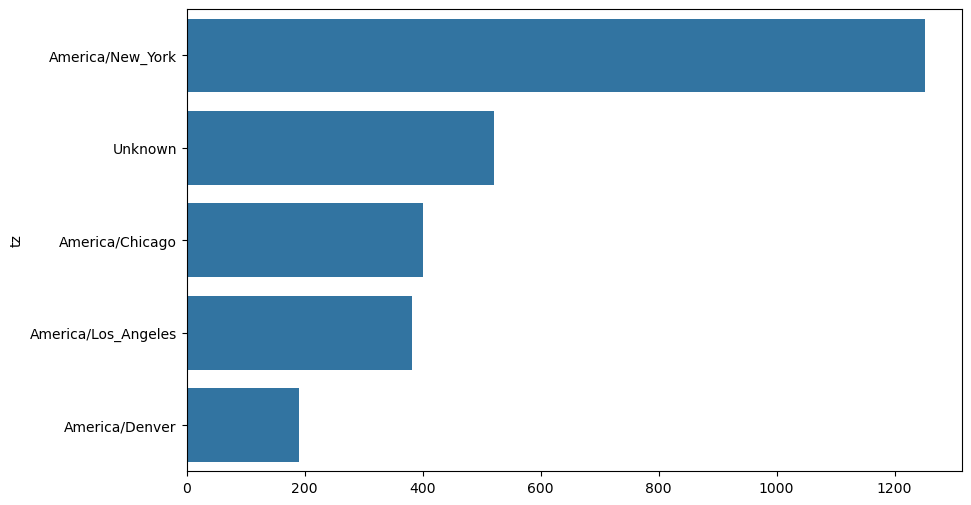

In [18]:
import seaborn as sns
subset = tz_counts.head()
sns.barplot(y=subset.index, x=subset.to_numpy())

**Nhận xét:**
- Top 5 múi giờ được đếm là: America/New_York (1251), Unknown (521), America/Chicago (400), America/Los_Angeles (382), và America/Denver (191).

2) Có bao nhiêu người dùng thiếu thông tin múi giờ hoặc quốc gia?

In [30]:
cols = ["tz", "c"]          
n = len(frame)

for col in cols:
    non_null = frame[col].notna().sum()
    missing  = n - non_null
    ratio    = non_null / n
    print(f"[{col}]  có dữ liệu: {non_null:,} | thiếu: {missing:,} | đầy đủ: {ratio:.2%}")



[tz]  có dữ liệu: 3,440 | thiếu: 120 | đầy đủ: 96.63%
[c]  có dữ liệu: 2,919 | thiếu: 641 | đầy đủ: 81.99%


**Nhận xét:**
-  Thông tin múi giờ (tz): Có 120 người dùng thiếu hoàn toàn thông tin múi giờ (giá trị NaN), vì cột tz chỉ có 3440 giá trị không thiếu trong tổng số 3560 mục. Ngoài ra, có 521 bản ghi có trường tz nhưng giá trị là chuỗi rỗng (""), được phân loại là "Unknown".
- Thông tin quốc gia (c): Có 641 người dùng thiếu thông tin quốc gia (giá trị NaN), vì cột c chỉ có 2919 giá trị không thiếu trong tổng số 3560 mục.

3) Những nguồn referrer (r) phổ biến nhất là gì (Facebook, Twitter, Google, v.v.)?

In [31]:
tz_counts = frame["r"].value_counts()
tz_counts.head()

r
direct                                 1585
http://www.facebook.com/                132
http://www.AwareMap.com/                121
http://www.shrewsbury-ma.gov/selco/      64
http://t.co/UKGBxj29                     54
Name: count, dtype: int64

**Nhận xét:**
- Chủ yếu lượt truy cập trực tiếp (gõ địa chỉ web, bookmark) hoặc không xác định được nguồn đếm là nguồn lớn nhất (1585)
- Tiếp theo thì Facebook (132), AwareMap (121).

#### 4.2 Phân tích tương quan

##### 4.2.1. Thiết bị

1) Tỷ lệ người dùng Windows vs Non-Windows là bao nhiêu?

In [32]:
results = pd.Series([x.split()[0] for x in frame["a"].dropna()])
results.head(5)
results.value_counts().head(8)

Mozilla/5.0                 2594
Mozilla/4.0                  601
GoogleMaps/RochesterNY       121
Opera/9.80                    34
TEST_INTERNET_AGENT           24
GoogleProducer                21
Mozilla/6.0                    5
BlackBerry8520/5.0.0.681       4
Name: count, dtype: int64

**Nhận xét:**
- Có 8 trình duyệt mà người dùng sử dụng, trong đó Mozilla/5.0 và Mozilla/4.0 chiếm đa số người dùng truy cập

In [33]:
cframe = frame[frame["a"].notna()].copy()
cframe["os"] = np.where(cframe["a"].str.contains("Windows"),
                        "Windows", "Not Windows")
cframe["os"].head(5)

0        Windows
1    Not Windows
2        Windows
3    Not Windows
4        Windows
Name: os, dtype: object

**Nhận xét:**
- Cột "os" để gán nhãn các giá trị Windowns và Not Windowns

In [34]:
by_tz_os = cframe.groupby(["tz", "os"])
agg_counts = by_tz_os.size().unstack().fillna(0)
agg_counts.head()

os,Not Windows,Windows
tz,,
,245.0,276.0
Africa/Cairo,0.0,3.0
Africa/Casablanca,0.0,1.0
Africa/Ceuta,0.0,2.0
Africa/Johannesburg,0.0,1.0


**Nhận xét:**
- Liệt kê các múi giờ nếu như không xuất hiện người dùng có sài hệ điều hành thì fill NaN vào.

In [36]:
indexer = agg_counts.sum("columns").argsort()
indexer.values[:10]

array([24, 20, 21, 92, 87, 53, 54, 57, 26, 55], dtype=int64)

**Nhận xét:**
- argsort() trả về một mảng chỉ mục (index array) cho phép sắp xếp Series đó theo thứ tự tăng dần (ascending order). Mảng chỉ mục này cho biết thứ tự các hàng phải được sắp xếp để tổng số lượt truy cập tăng dần.
> Lấy 10 múm giờ phổ biến nhất bằng cách chọn 10 phần tử cuối cùng của indexer


In [37]:
count_subset = agg_counts.take(indexer[-10:])
count_subset

os,Not Windows,Windows
tz,,
America/Sao_Paulo,13.0,20.0
Europe/Madrid,16.0,19.0
Pacific/Honolulu,0.0,36.0
Asia/Tokyo,2.0,35.0
Europe/London,43.0,31.0
America/Denver,132.0,59.0
America/Los_Angeles,130.0,252.0
America/Chicago,115.0,285.0
,245.0,276.0


 **Nhận xét:**
 - Người dùng Windows (Windows): Tổng cộng 2076 lượt (ví dụ: America/New_York có 912 Windows).
- Người dùng Non-Windows (Not Windows): Tổng cộng 1023 lượt (ví dụ: America New_York có 339 Non-Windows).
- Giá trị không xác định (chuỗi rỗng ""): 245 lượt "Not Windows" và 276 lượt "Windows".

2) Phân bố hệ điều hành khác nhau theo múi giờ ra sao?

<Axes: xlabel='total', ylabel='tz'>

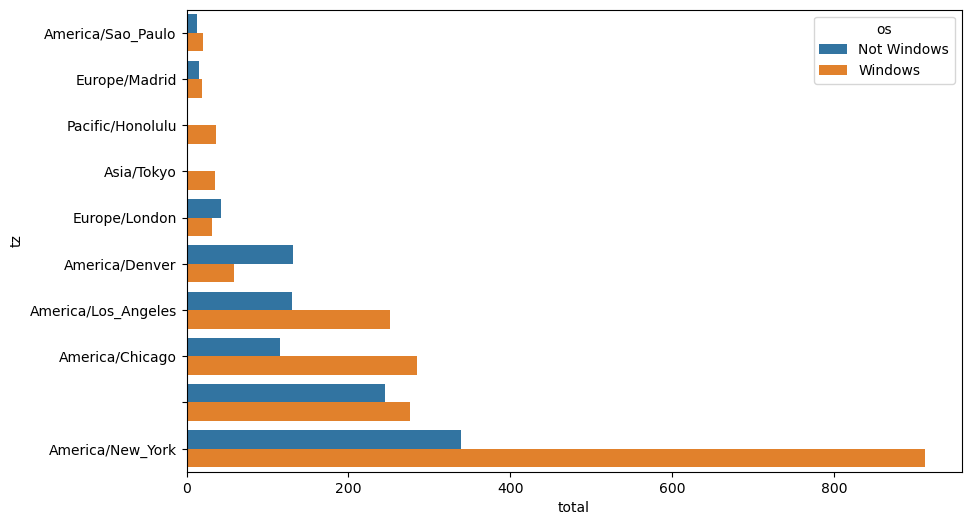

In [39]:
count_subset = count_subset.stack()
count_subset.name = "total"
count_subset = count_subset.reset_index()
count_subset.head(10)
sns.barplot(x="total", y="tz", hue="os",  data=count_subset)

**Nhận xét:**

Phân tích tỷ lệ phần trăm (đã chuẩn hóa để tổng bằng 1 trong mỗi múi giờ):

- Các múi giờ như America/New_York, America/Chicago, America/Los_Angeles, và Pacific/Honolulu cho thấy người dùng Windows chiếm tỷ lệ rất cao.
- Ngược lại, các múi giờ nhỏ hơn hoặc quốc tế như Europe/London có tỷ lệ người dùng Non-Windows cao hơn so với người dùng Windows (43 vs 31), và America/Denver có số lượng người dùng Non-Windows cao hơn đáng kể (132 vs 59).

3) Có sự khác biệt rõ rệt giữa các vùng (East Coast vs West Coast)?

**Nhận xét:**

Dựa trên dữ liệu đã nhóm:

- East Coast (America/New_York): Rất lớn, tổng cộng 1251 lượt truy cập, với tỷ lệ người dùng Windows cao hơn rõ rệt (912 Windows so với 339 Non-Windows).
- Midwest (America/Chicago): Tổng cộng 400 lượt truy cập, với tỷ lệ người dùng Windows cao hơn (285 Windows so với 115 Non-Windows).
- West Coast (America/Los_Angeles): Tổng cộng 382 lượt truy cập, với tỷ lệ người dùng Windows cao hơn (252 Windows so với 130 Non-Windows).
- Rocky Mountain (America/Denver): Tổng cộng 191 lượt truy cập, nhưng đáng chú ý là có nhiều người dùng Non-Windows hơn (132 Non-Windows so với 59 Windows).
> Kết luận: Có sự khác biệt: khu vực Bờ Đông và Midwest có số lượng tuyệt đối cao nhất và tỷ lệ Windows áp đảo, trong khi Denver có tỷ lệ Non-Windows chiếm ưu thế.

##### 4.2.2. Khung hành vi thời gian

1) Khung giờ (theo t) nào có lượng truy cập cao nhất?

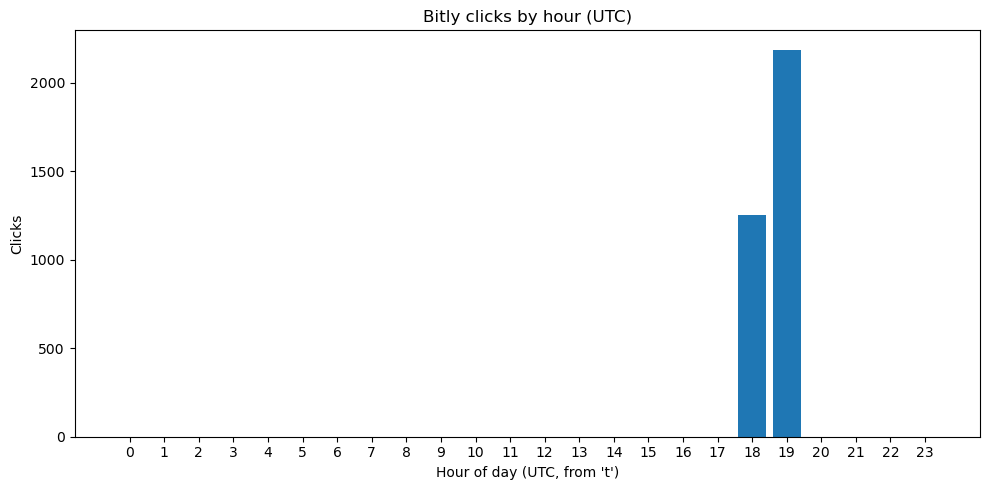

In [46]:
frame = frame[frame["t"].notna()].copy()
frame["t"] = pd.to_numeric(frame["t"], errors="coerce")
frame = frame[frame["t"].notna()]
frame["t_dt"] = pd.to_datetime(frame["t"], unit="s", utc=True)
frame["t_hour"] = frame["t_dt"].dt.hour

# (1) Đếm số click theo giờ UTC và vẽ biểu đồ cột
hour_counts = frame["t_hour"].value_counts().sort_index()
top_hour = int(hour_counts.idxmax()) if not hour_counts.empty else None
top_hour_count = int(hour_counts.max()) if not hour_counts.empty else 0

plt.figure(figsize=(10, 5))
hours = list(range(24))
counts = [hour_counts.get(h, 0) for h in hours]
plt.bar(hours, counts)
plt.xticks(hours)
plt.xlabel("Hour of day (UTC, from 't')")
plt.ylabel("Clicks")
plt.title("Bitly clicks by hour (UTC)")
plt.tight_layout()
plt.show()

**Nhận xét:**
- Khung giờ (UTC) có lượng truy cập cao nhất: 19h (≈ 2,188 clicks). 


2) Có mối tương quan giữa thời điểm tạo link (hc) và thời điểm click (t) không?

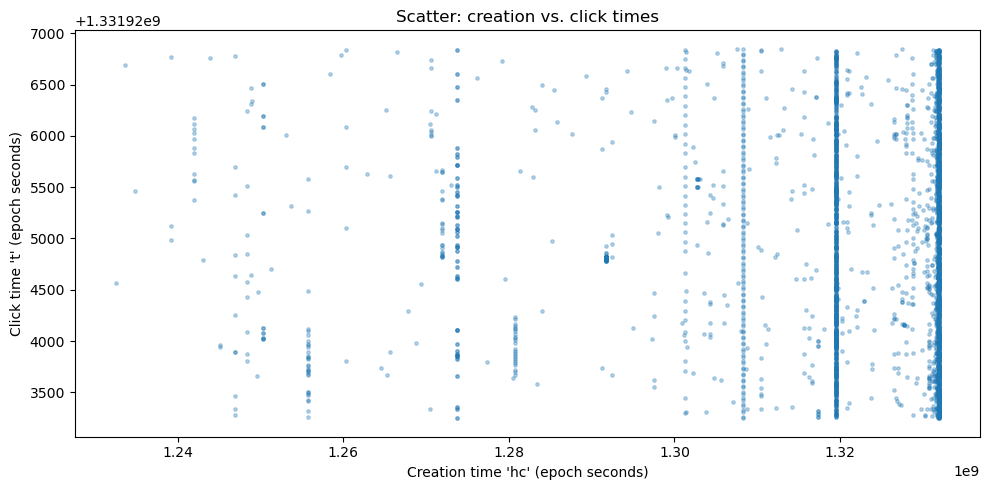

In [53]:
# chọn dữ liệu tránh dữ liệu missing và nan/null
df_corr = frame[frame["hc"].notna()].copy()
df_corr["hc"] = pd.to_numeric(df_corr["hc"], errors="coerce")
df_corr = df_corr[df_corr["hc"].notna()]

# Vẽ scatter hc vs t
plt.figure(figsize=(10, 5))
plt.scatter(df_corr["hc"], df_corr["t"], s=6, alpha=0.3)
plt.xlabel("Creation time 'hc' (epoch seconds)")
plt.ylabel("Click time 't' (epoch seconds)")
plt.title("Scatter: creation vs. click times")
plt.tight_layout()
plt.show()


**Nhận xét:**
- Các dữ liệu click phân bố rãi rác trên toàn bộ mốc thời gian. Cho nên không có sự tương quan nào giữa thời điểm tạo link (hc) với thời điểm click

##### 4.2.3. Địa lý

1) Những bang (gr) hoặc thành phố (cy) nào có lượng truy cập lớn nhất?

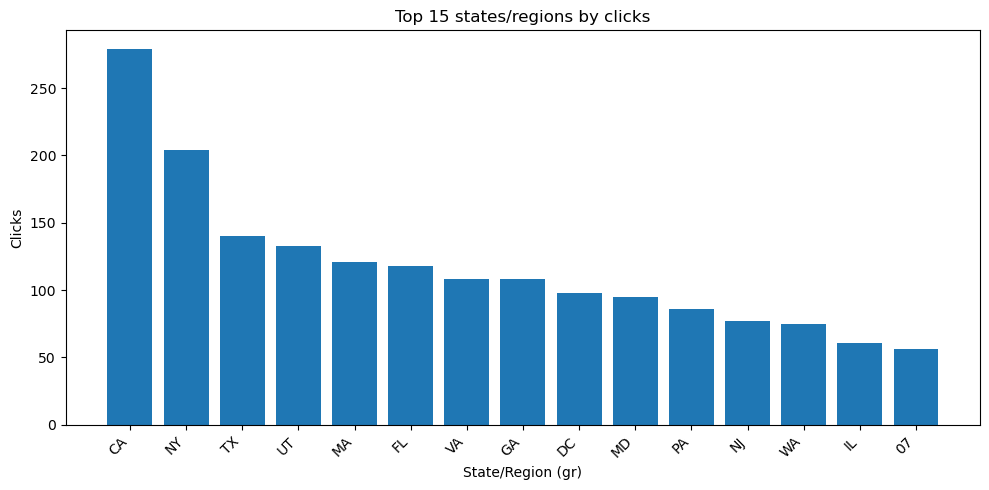

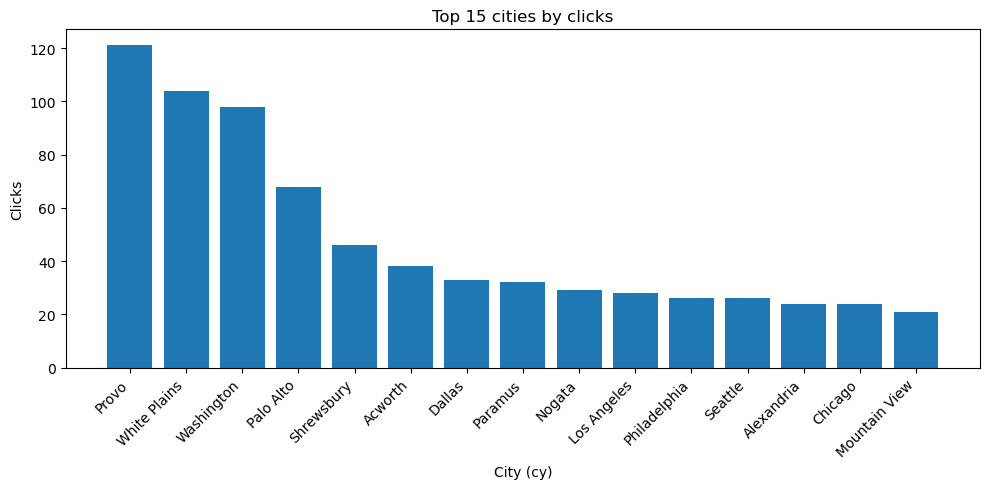

In [55]:
top_gr = frame["gr"].dropna().value_counts().head(15)
top_cy = frame["cy"].dropna().value_counts().head(15)

plt.figure(figsize=(10,5))
plt.bar(range(len(top_gr)), top_gr.values)
plt.xticks(range(len(top_gr)), top_gr.index, rotation=45, ha="right")
plt.xlabel("State/Region (gr)"); plt.ylabel("Clicks"); plt.title("Top 15 states/regions by clicks")
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
plt.bar(range(len(top_cy)), top_cy.values)
plt.xticks(range(len(top_cy)), top_cy.index, rotation=45, ha="right")
plt.xlabel("City (cy)"); plt.ylabel("Clicks"); plt.title("Top 15 cities by clicks")
plt.tight_layout(); plt.show()

**Nhận xét:**

Đối với bang (gr):

- Với các bang như CA (Bang California ), NY (Tiểu bang New York) chiếm lượng truy cập lớn nhất. Đon giản đây là CA là bang có số dân lớn nhất, và NY có vị trí thứ 4 tại Hoa Kỳ.

Đối với thành phố (cy):

- Thành phố Provo (Utah), White Plains (New York), Washington (Columbia) và Palo Alto (California) là những thành phố có lượng truy cập nhiều nhất. Ở đây có thể thấy các thành phố này thuộc các bang có lượng truy cập nhiều vì thế dễ hiểu các thành phố nằm trong các bang đó cũng chiếm lượng truy cập nhiều


2) Người dùng từ ngoài nước Mỹ (c != 'US') chiếm bao nhiêu phần trăm?

In [56]:
valid_c = frame["c"].notna()
non_us = (frame.loc[valid_c, "c"] != "US").sum()
total_c = valid_c.sum()
pct_non_us = (non_us / total_c * 100.0) if total_c else 0.0
print(f"Users from outside the US: {non_us:,}/{total_c:,} = {pct_non_us:.2f}%")

Users from outside the US: 614/2,919 = 21.03%


**Nhận xét:**
- Với lượng người dùng là 2,919 thì những người ngoài nước Mỹ là 614 thì chiếm tỷ lệ 21.03%. Cho thấy chiếm 1/4 tỷ lệ người dùng.

##### 4.2.4. Nguồn truy cập

1) Mạng xã hội nào chiếm tỉ lệ referrer cao nhất?

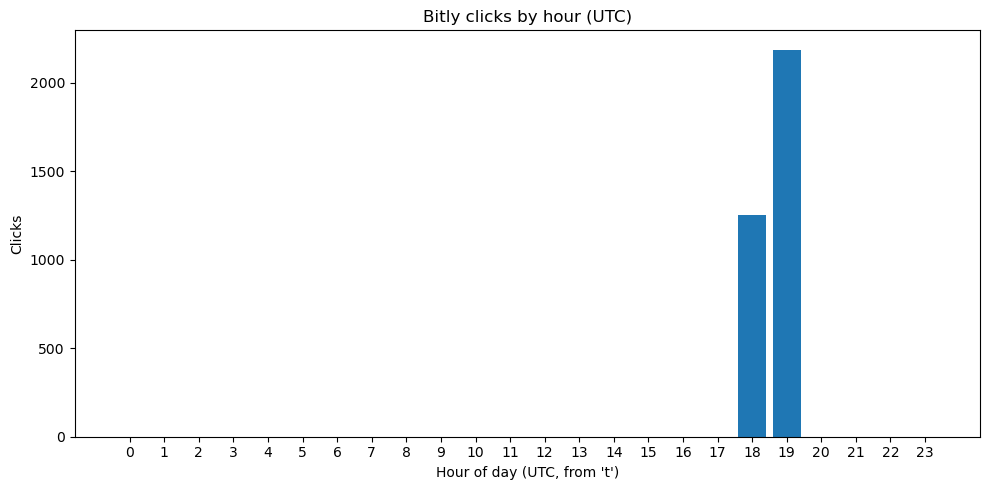

In [ ]:
is_social = df["ref_category"].isin(set(social_map.values()))
social_counts = df.loc[is_social, "ref_category"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(range(len(social_counts)), social_counts.values)
plt.xticks(range(len(social_counts)), social_counts.index, rotation=45, ha="right")
plt.xlabel("Social network"); plt.ylabel("Clicks"); plt.title("Social referrer counts")
plt.tight_layout(); plt.show()

if not social_counts.empty:
    top_social = social_counts.idxmax()
    share = social_counts.max() / social_counts.sum() * 100.0
    print(f"Top social referrer: {top_social} ({share:.2f}% of social clicks)")

**Nhận xét:**
- Khung giờ (UTC) có lượng truy cập cao nhất: 19h (≈ 2,188 clicks). 

**NGHIỆM THU PHÂN TÍCH**
- 

# KẾT THÚC